# 📊 Rule-Based Financial Text Classifier — Reuters-21578
## Running on `df_traditional.csv` with Match Analysis

**Dataset**: `df_traditional.csv` — 11,302 preprocessed (stemmed) Reuters articles  
**Task**: Multi-label classification → 100+ Reuters categories  
**Approach**: Keyword + regex rule engine, calibrated for stemmed text  

---
### Notebook Structure
1. Load & Explore Data  
2. Rule Dictionary (all categories with clear keyword rules)  
3. Classifier Engine  
4. Run on Full Dataset & Compute Metrics   
5. Per-Category Breakdown  
6. Summary & Observations  


## 1. Setup & Data Loading

In [1]:
import re
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 60)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Libraries loaded")


Libraries loaded


In [2]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/lithikhab/df-traditional/df_traditional.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nSingle-label rows: {(df['labels'].str.count('|') == 0).sum()}")
print(f"Multi-label rows : {(df['labels'].str.count('|') > 0).sum()}")

# Parse labels into lists
df['label_list'] = df['labels'].apply(lambda x: [l.strip() for l in str(x).split('|')])

# Count all unique labels
all_label_counts = Counter()
for ll in df['label_list']:
    for l in ll:
        all_label_counts[l] += 1

print(f"\nTotal unique labels: {len(all_label_counts)}")
print("\nTop 20 labels by frequency:")
for label, cnt in all_label_counts.most_common(20):
    bar = '█' * (cnt // 50)
    print(f"  {label:20s} {cnt:5d}  {bar}")


Shape: (11302, 2)
Columns: ['text', 'labels']

Single-label rows: 0
Multi-label rows : 11302

Total unique labels: 119

Top 20 labels by frequency:
  earn                  3961  ███████████████████████████████████████████████████████████████████████████████
  acq                   2445  ████████████████████████████████████████████████
  money-fx               796  ███████████████
  crude                  627  ████████████
  grain                  622  ████████████
  trade                  549  ██████████
  interest               511  ██████████
  wheat                  305  ██████
  ship                   297  █████
  corn                   253  █████
  dlr                    216  ████
  oilseed                192  ███
  sugar                  183  ███
  money-supply           182  ███
  gnp                    163  ███
  coffee                 145  ██
  veg-oil                137  ██
  gold                   135  ██
  nat-gas                130  ██
  soybean                120  ██


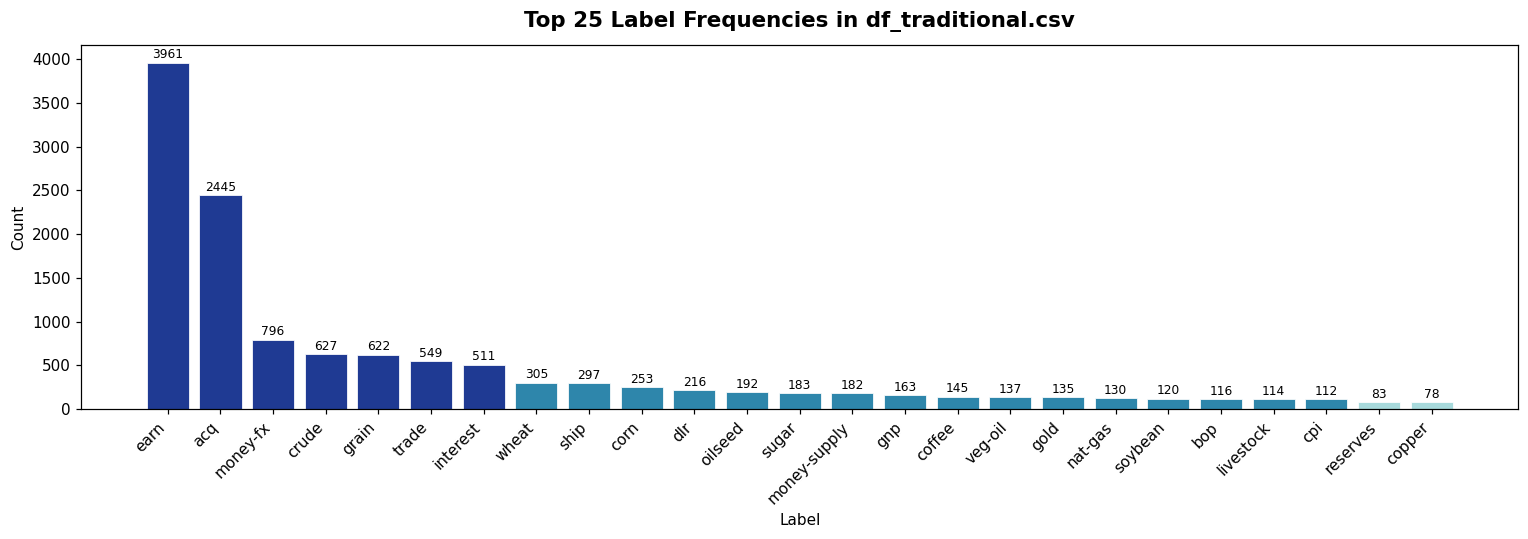

In [3]:
# Show label distribution chart
top_labels = [k for k, v in all_label_counts.most_common(25)]
top_counts = [all_label_counts[k] for k in top_labels]

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#1F3A93' if c > 500 else '#2E86AB' if c > 100 else '#A8DADC' for c in top_counts]
bars = ax.bar(top_labels, top_counts, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Top 25 Label Frequencies in df_traditional.csv', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Label')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
for bar, cnt in zip(bars, top_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(cnt), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


## 2. Rule Dictionary

> **Important**: The text in `df_traditional.csv` is **already stemmed** (e.g. "earnings" → "earn", "acquired" → "acquir", "prices" → "pric"). All keyword rules below are written to match **stemmed tokens**.

Each category rule contains:
- `keywords` — stemmed terms to count (TF-style)
- `patterns` — regex for structural patterns  
- `neg_kw` — terms that penalise the score (30% reduction per hit)
- `weight` — base multiplier (default 1.0, higher for rare/specific categories)


In [4]:
# ═══════════════════════════════════════════════════════════════════
#  RULE DICTIONARY  —  Calibrated for STEMMED text (Reuters-21578)
#  
#  TEXT is already stemmed: "earnings"→"earn", "prices"→"pric",
#  "acquired"→"acquir", "oil"→"oil", "interest"→"interest"
# ═══════════════════════════════════════════════════════════════════

RULES = {

    # ── CORE 8 REUTERS CATEGORIES ─────────────────────────────────

    "earn": {
        "keywords": [
            "earn", "profit", "loss", "reven", "net", "qtr", "shr",
            "dividend", "eps", "per share", "annualized", "fiscal",
            "oper profit", "oper loss", "pretax", "incom", "mth",
            "annual", "quarterli", "loss carryforward", "extraordi",
        ],
        "patterns": [
            r"\b(net|oper)\s+(profit|loss|incom)\b",
            r"\bshr\b.{0,30}\bloss\b",
            r"\bshr\b.{0,30}\bprofit\b",
            r"\bqtr\b",
            r"\brev\b.{0,20}\bmlns?\b",
        ],
        "neg_kw": [],
        "weight": 1.0,
    },

    "acq": {
        "keywords": [
            "acquir", "merger", "takeover", "buyout", "purchas", "acquis",
            "stake", "warrant", "tender", "hostile", "leverag",
            "minorit", "control interest", "definit agre", "deal clos",
            "sal common", "complet sal", "common stock purchas",
        ],
        "patterns": [
            r"\b(acquir|buy|purchas)\b.{0,30}\b(stake|share|interest|common)\b",
            r"\b(agre|plan|announc)\b.{0,20}\b(acquir|buy|merg|purchas)\b",
            r"\btender offer\b",
        ],
        "neg_kw": [],
        "weight": 1.0,
    },

    "money-fx": {
        "keywords": [
            "dollar", "yen", "sterling", "franc", "currenc", "exchang rate",
            "forex", "monetari", "foreign exchang", "devaluat", "revaluat",
            "appreciat", "depreciat", "central bank", "g-7", "louvr",
            "plaza", "intervention", "dlr", "monei market",
        ],
        "patterns": [
            r"\b(dollar|yen|sterling|franc)\b.{0,20}\b(fell|ros|gain|lost|strengthen|weaken)\b",
            r"\bexchang rate\b",
            r"\bcentral bank\b.{0,30}\b(interven|support|sell|bui)\b",
        ],
        "neg_kw": [],
        "weight": 1.0,
    },

    "grain": {
        "keywords": [
            "grain", "wheat", "corn", "sorghum", "barley", "oat",
            "crop", "harvest", "plant", "yield", "bushel", "agricultur",
            "usda", "farm", "drought", "rainfall", "coars grain",
            "feed grain", "export registr",
        ],
        "patterns": [
            r"\b(wheat|corn|grain|sorghum|barley|oat)\b.{0,20}\b(pric|export|import|crop|yield|harvest)\b",
            r"\busda\b",
            r"\bbushel\b",
        ],
        "neg_kw": [],
        "weight": 1.0,
    },

    "crude": {
        "keywords": [
            "crud", "oil", "petroleum", "opec", "barrel", "brent",
            "wti", "refiner", "gasolin", "energi", "offshor", "pipelin",
            "drill", "explor", "output quota", "oil pric",
            "west texa intermedi", "light sweet",
        ],
        "patterns": [
            r"\b(crud|oil|petroleum)\b.{0,20}\b(pric|product|output|export|import)\b",
            r"\bopec\b",
            r"\bbarrel\b",
            r"\bbbl\b",
        ],
        "neg_kw": [],
        "weight": 1.0,
    },

    "trade": {
        "keywords": [
            "trade", "export", "import", "tariff", "trade deficit",
            "trade surplu", "trade balanc", "trade war", "protect",
            "sanction", "embargo", "quota", "custom", "wto",
            "free trade", "bilateral", "trade polic", "anti-dump",
            "countervail", "trade disput",
        ],
        "patterns": [
            r"\btrade\b.{0,20}\b(deficit|surplu|balanc|gap|war|deal|agre)\b",
            r"\b(import|export)\b.{0,20}\b(ban|restrict|tariff|duti|quota)\b",
            r"\btariff\b",
        ],
        "neg_kw": [],
        "weight": 1.0,
    },

    "interest": {
        "keywords": [
            "interest", "rate", "federal fund", "prime rate", "libor",
            "treasuri yield", "bond yield", "discount rate",
            "monetari polici", "tighten", "easing", "quantit",
            "rate decis", "fomc", "bps", "basi point",
            "yield curv", "invert yield", "benchmark rate",
            "certifica deposit", "cd rat",
        ],
        "patterns": [
            r"\binterest\b.{0,20}\brate\b",
            r"\b(fomc|fed reserv)\b",
            r"\bbasi point\b",
            r"\byield curv\b",
            r"\bcd rat\b",
        ],
        "neg_kw": [],
        "weight": 1.0,
    },

    "ship": {
        "keywords": [
            "ship", "vessel", "tanker", "freighter", "cargo",
            "freight", "port", "harbor", "maritim", "seaborn",
            "container", "bulk carrier", "ocean freight",
            "charter", "tonnag", "drybulk", "lin", "shiplift",
        ],
        "patterns": [
            r"\b(ship|vessel|tanker|freighter)\b",
            r"\bfreight\b.{0,20}\b(rate|cost|capac|demand)\b",
            r"\bport\b.{0,20}\b(congest|delay|arriv|departur)\b",
        ],
        "neg_kw": [],
        "weight": 1.0,
    },

    # ── COMMODITIES ────────────────────────────────────────────────

    "cocoa": {
        "keywords": ["cocoa", "bahia", "cacao", "chocolate", "grind", "temporao", "comissaria"],
        "patterns": [r"\bcocoa\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "coffee": {
        "keywords": ["coffe", "ico", "arabica", "robusta", "export quota", "coffe pric",
                     "green coffe", "coffe board"],
        "patterns": [r"\bcoffe\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "sugar": {
        "keywords": ["sugar", "sweetener", "cane", "beet", "sugar quota",
                     "sugar import", "raw sugar", "refin sugar"],
        "patterns": [r"\bsugar\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "wheat": {
        "keywords": ["wheat", "bread wheat", "hard wheat", "soft wheat", "winter wheat",
                     "spring wheat", "flour", "milling"],
        "patterns": [r"\bwheat\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "corn": {
        "keywords": ["corn", "maiz", "cornglut", "corn pric", "corn export",
                     "yellow corn", "corn crop"],
        "patterns": [r"\bcorn\b", r"\bmaiz\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "soybean": {
        "keywords": ["soybean", "soi", "soya", "soybean oil", "soybean meal",
                     "soybean crop", "soybean export"],
        "patterns": [r"\bsoybean\b", r"\bsoi\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "oilseed": {
        "keywords": ["oilse", "oilseed", "veget oil", "crushings", "oil crop",
                     "sunflow", "rapese", "cottonseed", "palm"],
        "patterns": [r"\boilse\b", r"\boilseed\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "veg-oil": {
        "keywords": ["veg-oil", "veget oil", "palm oil", "soy oil", "sun oil",
                     "lin oil", "coconut oil", "cotton oil", "edible oil"],
        "patterns": [r"\bveget\s+oil\b", r"\bveg-oil\b", r"\bpalm\s+oil\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "palm-oil": {
        "keywords": ["palm oil", "palm kernel", "cpo", "palmolein", "palmkernel"],
        "patterns": [r"\bpalm\b.{0,10}\boil\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "soy-oil": {
        "keywords": ["soy oil", "soybean oil", "soy-oil"],
        "patterns": [r"\bsoy.{0,3}oil\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "soy-meal": {
        "keywords": ["soy meal", "soybean meal", "soy-meal", "defatted soy"],
        "patterns": [r"\bsoy.{0,3}meal\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "sun-oil": {
        "keywords": ["sun oil", "sunflower oil", "sunoil", "sun-oil"],
        "patterns": [r"\bsun.{0,3}oil\b", r"\bsunoil\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "sunseed": {
        "keywords": ["sunse", "sunflow", "sunflowerse", "sunseed"],
        "patterns": [r"\bsunseed\b", r"\bsunflowerse\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "rapeseed": {
        "keywords": ["rapese", "canola", "rape oil", "rape meal", "rapeseeds"],
        "patterns": [r"\brapese\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "linseed": {
        "keywords": ["linse", "linseed", "flaxse", "lin oil", "lin meal"],
        "patterns": [r"\blinse\b", r"\blinseed\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "lin-oil": {
        "keywords": ["lin oil", "linoil", "linseed oil"],
        "patterns": [r"\blin.{0,3}oil\b", r"\blinoil\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "cotton": {
        "keywords": ["cotton", "fiber", "lint", "cotton pric", "upland cotton",
                     "cotton export", "cotton import", "textile"],
        "patterns": [r"\bcotton\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "rubber": {
        "keywords": ["rubber", "latex", "natur rubber", "synthetic rubber",
                     "tir", "rubber pric", "rubber export"],
        "patterns": [r"\brubber\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "rice": {
        "keywords": ["rice", "paddi", "milled rice", "rough rice", "rice export",
                     "rice pric", "oryza"],
        "patterns": [r"\brice\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "barley": {
        "keywords": ["barlei", "barley", "malt", "brewi"],
        "patterns": [r"\bbarlei\b", r"\bbarley\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "oat": {
        "keywords": ["oat", "oats"],
        "patterns": [r"\boat\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "sorghum": {
        "keywords": ["sorghum", "milo", "grain sorghum"],
        "patterns": [r"\bsorghum\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "orange": {
        "keywords": ["orang", "citrus", "juice", "florida orang", "fcoj",
                     "frozen concentr"],
        "patterns": [r"\borang\b", r"\bcitrus\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "potato": {
        "keywords": ["potato", "spud"],
        "patterns": [r"\bpotato\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "groundnut": {
        "keywords": ["groundnut", "peanut", "arachis"],
        "patterns": [r"\bgroundnut\b", r"\bpeanut\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "tea": {
        "keywords": ["tea", "camellia", "tea auction", "tea board", "tea export"],
        "patterns": [r"\btea\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "tapioca": {
        "keywords": ["tapioca", "cassava", "manioc"],
        "patterns": [r"\btapioca\b", r"\bcassava\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "meal-feed": {
        "keywords": ["meal-feed", "fishmeal", "feed meal", "protein meal",
                     "meal feed", "copra cake", "citruspulp"],
        "patterns": [r"\bmeal.feed\b", r"\bfishmeal\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    # ── METALS ────────────────────────────────────────────────────

    "gold": {
        "keywords": ["gold", "bullion", "comex gold", "gold pric", "gold reserv",
                     "gold bar", "spot gold", "karat"],
        "patterns": [r"\bgold\b.{0,20}\b(pric|oz|reserv|bullion)\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "silver": {
        "keywords": ["silver", "silver pric", "silver bullion", "comex silver"],
        "patterns": [r"\bsilver\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "copper": {
        "keywords": ["copper", "cathod", "copper pric", "lme copper", "copper min",
                     "comex copper"],
        "patterns": [r"\bcopper\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "alum": {
        "keywords": ["aluminium", "aluminum", "alum", "bauxite", "alumina",
                     "lme aluminium"],
        "patterns": [r"\balum\b", r"\bbauxite\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "lead": {
        "keywords": ["lead", "lme lead", "lead pric", "lead product"],
        "patterns": [r"\blead\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "zinc": {
        "keywords": ["zinc", "lme zinc", "zinc pric", "galvani"],
        "patterns": [r"\bzinc\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "tin": {
        "keywords": ["tin", "lme tin", "tin pric", "ita", "itc"],
        "patterns": [r"\btin\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "nickel": {
        "keywords": ["nickel", "lme nickel", "nickel pric", "stainless"],
        "patterns": [r"\bnickel\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "platinum": {
        "keywords": ["platinum", "palladium", "pgm", "rhodium"],
        "patterns": [r"\bplatinum\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "palladium": {
        "keywords": ["palladium", "pgm"],
        "patterns": [r"\bpalladium\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "iron-steel": {
        "keywords": ["iron", "steel", "hot roll", "cold roll", "pig iron",
                     "scrap", "coil", "steel mill", "blast furnac"],
        "patterns": [r"\biron\b", r"\bsteel\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "strategic-metal": {
        "keywords": ["strategic metal", "chromium", "manganes", "cobalt",
                     "tungsten", "molybdenum", "vanadium"],
        "patterns": [r"\bstrategic.metal\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    # ── ENERGY ─────────────────────────────────────────────────────

    "nat-gas": {
        "keywords": ["natur ga", "nat gas", "lng", "pipelin", "gas field",
                     "gas produc", "gas pric", "liquefi"],
        "patterns": [r"\bnatur\s+ga\b", r"\bnat.gas\b", r"\blng\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "gas": {
        "keywords": ["gasolin", "petrol", "octane", "gas station", "unleaded",
                     "fuel ga", "gas pric", "refiner"],
        "patterns": [r"\bgasolin\b", r"\boctane\b"],
        "neg_kw": ["natur ga"],
        "weight": 1.5,
    },

    "heat": {
        "keywords": ["heat", "heat oil", "fuel oil", "heating fuel", "distillat"],
        "patterns": [r"\bheat\s+oil\b", r"\bfuel\s+oil\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "fuel": {
        "keywords": ["fuel", "jet fuel", "aviation fuel", "kerosin", "aviation"],
        "patterns": [r"\bfuel\b"],
        "neg_kw": [],
        "weight": 1.3,
    },

    "jet": {
        "keywords": ["jet", "aviat fuel", "kerosin", "jet fuel"],
        "patterns": [r"\bjet\s+fuel\b", r"\bkerosin\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "naphtha": {
        "keywords": ["naphtha", "petrochemic", "feedstock"],
        "patterns": [r"\bnaphtha\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "pet-chem": {
        "keywords": ["petrochemic", "pet-chem", "ethylen", "propylene", "polymer",
                     "plastics", "benzene", "xylene"],
        "patterns": [r"\bpetrochem\b", r"\bpet-chem\b", r"\bethylen\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "propane": {
        "keywords": ["propane", "lpg", "liquefied petroleum", "butane"],
        "patterns": [r"\bpropane\b", r"\blpg\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    # ── MACROECONOMICS ─────────────────────────────────────────────

    "gnp": {
        "keywords": ["gnp", "gdp", "gross nation", "gross domest", "econom growth",
                     "real gnp", "real gdp", "gdp growth"],
        "patterns": [r"\bgnp\b", r"\bgdp\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "cpi": {
        "keywords": ["cpi", "consum pric", "consum pric index", "inflat",
                     "retail pric", "cost of live"],
        "patterns": [r"\bcpi\b", r"\bconsum\s+pric\s+index\b", r"\bconsum\s+pric\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "wpi": {
        "keywords": ["wpi", "wholesal pric", "producer pric", "ppi"],
        "patterns": [r"\bwpi\b", r"\bwholesal\s+pric\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "bop": {
        "keywords": ["balanc of payment", "current account", "trade account",
                     "bop", "payment deficit", "payment surplu",
                     "current account deficit", "current account surplu"],
        "patterns": [r"\bbop\b", r"\bcurrent\s+account\b", r"\bbalanc\s+of\s+payment\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "ipi": {
        "keywords": ["ipi", "industri product", "industri output", "manufactur output",
                     "factor output", "capac util"],
        "patterns": [r"\bipi\b", r"\bindustri\s+product\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "money-supply": {
        "keywords": ["monei suppli", "money supply", "m1", "m2", "m3",
                     "monetari aggreg", "credit growth", "broad monei",
                     "narrow monei", "asset monei mutual", "monei mutual"],
        "patterns": [r"\bmonei\s+suppli\b", r"\bm[123]\b", r"\bmutual\s+fund\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "reserves": {
        "keywords": ["reserv", "foreign reserv", "gold reserv", "fx reserv",
                     "offici reserv", "central bank reserv"],
        "patterns": [r"\bforeign\s+reserv\b", r"\bgold\s+reserv\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "jobs": {
        "keywords": ["job", "unemploy", "employ", "payrol", "labor market",
                     "job creat", "jobless", "unemploy rat"],
        "patterns": [r"\bunemploy\b", r"\bjobless\b", r"\bpayrol\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "housing": {
        "keywords": ["hous", "real estat", "mortgage", "home sal", "hous start",
                     "hous permit", "construct", "builder"],
        "patterns": [r"\bhous\b.{0,20}\b(start|permit|sal|market)\b", r"\bmortgag\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "retail": {
        "keywords": ["retail", "retail sal", "consumer spend", "store sal",
                     "retail sales"],
        "patterns": [r"\bretail\s+sal\b", r"\bretail\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "income": {
        "keywords": ["person incom", "disposabl incom", "household incom",
                     "incom growth", "wage", "earningper"],
        "patterns": [r"\bperson\s+incom\b", r"\bdisposabl\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "inventories": {
        "keywords": ["inventori", "stock level", "inventori build", "destocking",
                     "inventori change"],
        "patterns": [r"\binventori\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "instal-debt": {
        "keywords": ["instal debt", "consumer debt", "consumer credit",
                     "instalment", "credit card debt", "consumer loan"],
        "patterns": [r"\binstal.debt\b", r"\bconsumer\s+credit\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "lei": {
        "keywords": ["lei", "lead econom indicat", "leading indicat", "composite index"],
        "patterns": [r"\blei\b", r"\blead.*indicat\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    # ── CURRENCIES (specific) ─────────────────────────────────────

    "dlr": {
        "keywords": ["dlr", "dollar", "usd", "greenback", "dollar yen", "dollar mark"],
        "patterns": [r"\bdlr\b", r"\bu\.s\.\s+dollar\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "yen": {
        "keywords": ["yen", "japan currenc", "yen dollar", "boj", "bank japan"],
        "patterns": [r"\byen\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "dmk": {
        "keywords": ["mark", "dmk", "deutschmark", "german mark", "bundesbank"],
        "patterns": [r"\bdmk\b", r"\bdeuthmark\b", r"\bgerman\s+mark\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "stg": {
        "keywords": ["sterling", "pound", "stg", "british pound", "gbp"],
        "patterns": [r"\bsterl\b", r"\bstg\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "sfr": {
        "keywords": ["sfr", "swiss franc", "chf", "swissie"],
        "patterns": [r"\bsfr\b", r"\bswiss\s+franc\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "dfl": {
        "keywords": ["dfl", "guilder", "dutch florin", "netherlands guilder"],
        "patterns": [r"\bdfl\b", r"\bguilder\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "bfr": {
        "keywords": ["bfr", "belgian franc"],
        "patterns": [r"\bbfr\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "dkr": {
        "keywords": ["dkr", "danish krone"],
        "patterns": [r"\bdkr\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "nkr": {
        "keywords": ["nkr", "norwegian krone"],
        "patterns": [r"\bnkr\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "skr": {
        "keywords": ["skr", "swedish krona"],
        "patterns": [r"\bskr\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "lit": {
        "keywords": ["lit", "lira", "italian lira", "italian currenc"],
        "patterns": [r"\blit\b", r"\blira\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "can": {
        "keywords": ["canadian dollar", "loonie", "cad", "bank of canada"],
        "patterns": [r"\bcanadian\s+dollar\b", r"\bcad\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "austdlr": {
        "keywords": ["australian dollar", "aussie dollar", "aud"],
        "patterns": [r"\baustralian\s+dollar\b", r"\baustdlr\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "nzdlr": {
        "keywords": ["new zealand dollar", "nzd", "kiwi dollar"],
        "patterns": [r"\bnew\s+zealand\s+dollar\b", r"\bnzdlr\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "hk": {
        "keywords": ["hong kong dollar", "hkd", "hk dollar"],
        "patterns": [r"\bhk\s+dollar\b", r"\bhong\s+kong\s+dollar\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "ringgit": {
        "keywords": ["ringgit", "malaysian ringgit", "myr"],
        "patterns": [r"\bringgit\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "rupiah": {
        "keywords": ["rupiah", "indonesian rupiah", "idr"],
        "patterns": [r"\brupiah\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "peseta": {
        "keywords": ["peseta", "spanish peseta", "esp"],
        "patterns": [r"\bpeseta\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "saudriyal": {
        "keywords": ["saudi riyal", "riyal", "sar"],
        "patterns": [r"\briyal\b", r"\bsaudiyal\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "rand": {
        "keywords": ["rand", "south african rand", "zar"],
        "patterns": [r"\brand\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    # ── LIVESTOCK ─────────────────────────────────────────────────

    "livestock": {
        "keywords": ["livestock", "cattl", "hog", "pig", "poultri", "beef", "pork",
                     "sheep", "lamb", "feedlot"],
        "patterns": [r"\bcattl\b", r"\bpork\b", r"\blivestock\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "hog": {
        "keywords": ["hog", "pig", "pork belli", "lean hog"],
        "patterns": [r"\bhog\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "l-cattle": {
        "keywords": ["live cattl", "feeder cattl", "beef"],
        "patterns": [r"\blive\s+cattl\b", r"\bl-cattl\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "f-cattle": {
        "keywords": ["feeder cattl"],
        "patterns": [r"\bfeeder\s+cattl\b", r"\bf-cattl\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "carcass": {
        "keywords": ["carcas", "beef carcas", "pork carcas", "poultri"],
        "patterns": [r"\bcarcas\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "pork-belly": {
        "keywords": ["pork belli", "bacon"],
        "patterns": [r"\bpork\s+belli\b", r"\bpork-belli\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    # ── OTHER COMMODITIES ─────────────────────────────────────────

    "lumber": {
        "keywords": ["lumber", "timber", "softwood", "hardwood", "plywood",
                     "forest product"],
        "patterns": [r"\blumber\b", r"\btimber\b"],
        "neg_kw": [],
        "weight": 1.5,
    },

    "plywood": {
        "keywords": ["plywood", "panel"],
        "patterns": [r"\bplywood\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "wool": {
        "keywords": ["wool", "fleece", "mohair", "textile fiber"],
        "patterns": [r"\bwool\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "fishmeal": {
        "keywords": ["fishmeal", "fish meal", "anchovi", "fish oil"],
        "patterns": [r"\bfishmeal\b", r"\bfish\s+meal\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "coconut": {
        "keywords": ["coconut", "copra"],
        "patterns": [r"\bcoconut\b", r"\bcopra\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "coconut-oil": {
        "keywords": ["coconut oil", "copra oil"],
        "patterns": [r"\bcoconut\s+oil\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "copra-cake": {
        "keywords": ["copra cake", "copra meal"],
        "patterns": [r"\bcopra\s+cake\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "palmkernel": {
        "keywords": ["palm kernel", "palmkernel"],
        "patterns": [r"\bpalmkernel\b", r"\bpalm\s+kernel\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "red-bean": {
        "keywords": ["red bean", "azuki", "adzuki"],
        "patterns": [r"\bred.bean\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "rye": {
        "keywords": ["rye"],
        "patterns": [r"\brye\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "castor-oil": {
        "keywords": ["castor oil", "castor"],
        "patterns": [r"\bcastor.oil\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "castorseed": {
        "keywords": ["castorseed", "castor seed"],
        "patterns": [r"\bcastorseed\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "citruspulp": {
        "keywords": ["citrus pulp", "citruspulp"],
        "patterns": [r"\bcitruspulp\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "cornglutenfeed": {
        "keywords": ["corn gluten", "corngluten"],
        "patterns": [r"\bcorngluten\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "corn-oil": {
        "keywords": ["corn oil"],
        "patterns": [r"\bcorn.oil\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "cotton-oil": {
        "keywords": ["cotton oil", "cottonseed oil"],
        "patterns": [r"\bcotton.oil\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "cottonseed": {
        "keywords": ["cottonseed"],
        "patterns": [r"\bcottonseed\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "rape-oil": {
        "keywords": ["rape oil", "canola oil"],
        "patterns": [r"\brake.oil\b", r"\bcanola\s+oil\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "rape-meal": {
        "keywords": ["rape meal", "canola meal"],
        "patterns": [r"\brake.meal\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "sun-meal": {
        "keywords": ["sunflower meal", "sun meal"],
        "patterns": [r"\bsun.meal\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "lin-meal": {
        "keywords": ["linseed meal", "lin meal"],
        "patterns": [r"\blin.meal\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "groundnut-oil": {
        "keywords": ["groundnut oil", "peanut oil"],
        "patterns": [r"\bgroundnut.oil\b", r"\bpeanut.oil\b"],
        "neg_kw": [],
        "weight": 1.8,
    },

    "cpu": {
        "keywords": ["cpu", "computer", "processor", "chip", "semiconductor"],
        "patterns": [r"\bcpu\b"],
        "neg_kw": [],
        "weight": 1.8,
    },
}

print(f"Rule dictionary loaded: {len(RULES)} categories defined")
print("\nCategories covered:")
for i, k in enumerate(RULES.keys()):
    print(f"  {k}", end="\n" if (i+1) % 6 == 0 else "\t")


✅ Rule dictionary loaded: 119 categories defined

Categories covered:
  earn	  acq	  money-fx	  grain	  crude	  trade
  interest	  ship	  cocoa	  coffee	  sugar	  wheat
  corn	  soybean	  oilseed	  veg-oil	  palm-oil	  soy-oil
  soy-meal	  sun-oil	  sunseed	  rapeseed	  linseed	  lin-oil
  cotton	  rubber	  rice	  barley	  oat	  sorghum
  orange	  potato	  groundnut	  tea	  tapioca	  meal-feed
  gold	  silver	  copper	  alum	  lead	  zinc
  tin	  nickel	  platinum	  palladium	  iron-steel	  strategic-metal
  nat-gas	  gas	  heat	  fuel	  jet	  naphtha
  pet-chem	  propane	  gnp	  cpi	  wpi	  bop
  ipi	  money-supply	  reserves	  jobs	  housing	  retail
  income	  inventories	  instal-debt	  lei	  dlr	  yen
  dmk	  stg	  sfr	  dfl	  bfr	  dkr
  nkr	  skr	  lit	  can	  austdlr	  nzdlr
  hk	  ringgit	  rupiah	  peseta	  saudriyal	  rand
  livestock	  hog	  l-cattle	  f-cattle	  carcass	  pork-belly
  lumber	  plywood	  wool	  fishmeal	  coconut	  coconut-oil
  copra-cake	  palmkernel	  re

## 3. Classifier Engine

In [5]:
# ═══════════════════════════════════════════════════════════
#  CLASSIFIER ENGINE
# ═══════════════════════════════════════════════════════════

def score_category(text: str, rules: dict) -> float:
    """
    Score how well a text matches one category's rules.
    
    Steps:
      1. Count keyword occurrences × weight
      2. Count regex pattern matches × weight × 2.0  (structural bonus)
      3. Apply 30% penalty for each negative keyword found
    """
    score = 0.0
    w = rules.get("weight", 1.0)

    # Step 1: keyword matching
    for kw in rules.get("keywords", []):
        cnt = len(re.findall(r'\b' + re.escape(kw) + r'\b', text))
        score += cnt * w

    # Step 2: pattern matching (2× bonus for structural specificity)
    for pat in rules.get("patterns", []):
        matches = re.findall(pat, text)
        score += len(matches) * w * 2.0

    # Step 3: negative keyword penalty
    for neg in rules.get("neg_kw", []):
        if re.search(r'\b' + re.escape(neg) + r'\b', text):
            score *= 0.7

    return score


def classify(text: str, threshold: float = 0.25) -> dict:
    """
    Classify text into one or more Reuters categories.
    
    Parameters
    ----------
    text      : Input text (stemmed)
    threshold : Min normalised score to include a label (0–1)
    
    Returns
    -------
    dict with 'predictions' (list), 'scores' (dict), 'raw_scores' (dict)
    """
    raw = {}
    for cat, rules in RULES.items():
        raw[cat] = score_category(text, rules)

    max_score = max(raw.values()) if any(raw.values()) else 1.0
    if max_score == 0:
        norm = {k: 0.0 for k in raw}
    else:
        norm = {k: v / max_score for k, v in raw.items()}

    # Sort descending
    norm_sorted = dict(sorted(norm.items(), key=lambda x: x[1], reverse=True))

    # Apply threshold
    preds = [k for k, v in norm_sorted.items() if v >= threshold]
    if not preds:
        preds = [list(norm_sorted.keys())[0]]  # always return at least 1

    return {
        "predictions": preds,
        "scores": norm_sorted,
        "raw_scores": raw,
        "top_score": max_score,
    }


# Quick sanity check
test_cases = [
    ("earn qtr net profit loss shr", "earn"),
    ("acquir purchas stake warrant tender", "acq"),
    ("cocoa bahia temporao", "cocoa"),
    ("crude oil opec barrel brent", "crude"),
    ("interest rate cd rat bank japan yen certifica", "interest"),
]

print("=== SANITY CHECK ===")
for text, expected in test_cases:
    result = classify(text)
    top3 = list(result['scores'].items())[:3]
    ok = "✅" if expected in result['predictions'] else "❌"
    print(f"{ok} Expected={expected:12s} | Got={result['predictions'][:3]} | Top3={top3}")


=== SANITY CHECK ===
✅ Expected=earn         | Got=['earn'] | Top3=[('earn', 1.0), ('acq', 0.0), ('money-fx', 0.0)]
✅ Expected=acq          | Got=['acq'] | Top3=[('acq', 1.0), ('earn', 0.0), ('money-fx', 0.0)]
✅ Expected=cocoa        | Got=['cocoa'] | Top3=[('cocoa', 1.0), ('earn', 0.0), ('acq', 0.0)]
✅ Expected=crude        | Got=['crude'] | Top3=[('crude', 1.0), ('earn', 0.0), ('acq', 0.0)]
✅ Expected=interest     | Got=['interest', 'yen'] | Top3=[('interest', 1.0), ('yen', 0.8571428571428571), ('money-fx', 0.14285714285714285)]


## 4. Run Classifier on Full Dataset & Compute Metrics

In [6]:
# ── Run on all 11,302 rows ──────────────────────────────────────────────────
print("Running classifier on all rows…")

results = []
for idx, row in df.iterrows():
    r = classify(row['text'], threshold=0.25)
    results.append({
        "idx":         idx,
        "text":        row['text'],
        "true_labels": set(row['label_list']),
        "pred_labels": set(r['predictions']),
        "scores":      r['scores'],
        "top_score":   r['top_score'],
    })

results_df = pd.DataFrame(results)
print(f"Done. {len(results_df)} rows classified.")


Running classifier on all rows…
Done. 11302 rows classified.


In [7]:
# ── Multi-label metrics ─────────────────────────────────────────────────────

def compute_multilabel_metrics(results):
    """Compute exact-match, subset accuracy, micro P/R/F1, and per-label stats."""
    
    all_labels_set = set()
    for r in results:
        all_labels_set |= r['true_labels']
    all_labels = sorted(all_labels_set)

    tp_total = fp_total = fn_total = 0
    exact_match = 0
    subset_match = 0   # predicted ⊆ true OR true ⊆ predicted
    
    per_label = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})

    for r in results:
        pred = r['pred_labels']
        true = r['true_labels']
        
        # Exact match
        if pred == true:
            exact_match += 1
        
        # Subset match (at least one correct, no spurious)
        if pred & true:  # any intersection
            subset_match += 1
        
        # Per-label TP/FP/FN
        for lbl in all_labels:
            in_pred = lbl in pred
            in_true = lbl in true
            if in_pred and in_true:
                per_label[lbl]['tp'] += 1
                tp_total += 1
            elif in_pred and not in_true:
                per_label[lbl]['fp'] += 1
                fp_total += 1
            elif not in_pred and in_true:
                per_label[lbl]['fn'] += 1
                fn_total += 1

    n = len(results)
    micro_p  = tp_total / (tp_total + fp_total) if (tp_total + fp_total) else 0
    micro_r  = tp_total / (tp_total + fn_total) if (tp_total + fn_total) else 0
    micro_f1 = 2*micro_p*micro_r/(micro_p+micro_r) if (micro_p+micro_r) else 0

    per_label_metrics = {}
    for lbl in all_labels:
        tp = per_label[lbl]['tp']
        fp = per_label[lbl]['fp']
        fn = per_label[lbl]['fn']
        p  = tp/(tp+fp) if (tp+fp) else 0
        r  = tp/(tp+fn) if (tp+fn) else 0
        f1 = 2*p*r/(p+r) if (p+r) else 0
        per_label_metrics[lbl] = {'precision': p, 'recall': r, 'f1': f1,
                                   'tp': tp, 'fp': fp, 'fn': fn}

    macro_f1 = np.mean([v['f1'] for v in per_label_metrics.values()])

    return {
        'exact_match_accuracy': exact_match / n,
        'subset_accuracy':      subset_match / n,
        'micro_precision':      micro_p,
        'micro_recall':         micro_r,
        'micro_f1':             micro_f1,
        'macro_f1':             macro_f1,
        'per_label':            per_label_metrics,
        'n':                    n,
    }

metrics = compute_multilabel_metrics(results)

print("=" * 55)
print("  OVERALL PERFORMANCE ON df_traditional.csv")
print("=" * 55)
print(f"  Total samples          : {metrics['n']:,}")
print(f"  Exact match accuracy   : {metrics['exact_match_accuracy']:.3f}  ({metrics['exact_match_accuracy']*100:.1f}%)")
print(f"  Subset accuracy        : {metrics['subset_accuracy']:.3f}  ({metrics['subset_accuracy']*100:.1f}%)")
print(f"  Micro Precision        : {metrics['micro_precision']:.3f}")
print(f"  Micro Recall           : {metrics['micro_recall']:.3f}")
print(f"  Micro F1               : {metrics['micro_f1']:.3f}")
print(f"  Macro F1               : {metrics['macro_f1']:.3f}")
print("=" * 55)


  OVERALL PERFORMANCE ON df_traditional.csv
  Total samples          : 11,302
  Exact match accuracy   : 0.468  (46.8%)
  Subset accuracy        : 0.825  (82.5%)
  Micro Precision        : 0.558
  Micro Recall           : 0.767
  Micro F1               : 0.646
  Macro F1               : 0.457


## 5. Correct Predictions — Where the Rules Work

Cases where `predicted_labels == true_labels` (exact match) or where every true label is correctly captured.


In [8]:
# ── Exact match examples ────────────────────────────────────────────────────
exact_correct = [r for r in results if r['pred_labels'] == r['true_labels']]
print(f"Exact matches: {len(exact_correct):,} / {len(results):,}  ({len(exact_correct)/len(results)*100:.1f}%)")

# Show a representative sample across different label types
sample_labels = ['earn', 'acq', 'crude', 'grain', 'cocoa', 'ship', 'sugar', 'gold']
print("\n=== SAMPLE EXACT MATCHES (by label) ===\n")

for lbl in sample_labels:
    hits = [r for r in exact_correct if lbl in r['true_labels']]
    if not hits:
        continue
    r = hits[0]
    top3_scores = list(r['scores'].items())[:3]
    print(f"{'─'*70}")
    print(f"  LABEL   : {sorted(r['true_labels'])}")
    print(f"  PREDICT : {sorted(r['pred_labels'])}")
    print(f"  TEXT    : {r['text'][:120]}…")
    print(f"  SCORES  : {[(k, round(v,3)) for k,v in top3_scores]}")
    print()


Exact matches: 5,285 / 11,302  (46.8%)

=== SAMPLE EXACT MATCHES (by label) ===

──────────────────────────────────────────────────────────────────────
  LABEL   : ['earn']
  PREDICT : ['earn']
  TEXT    : champion product ch approv split champion product board director approv two-for-on split common sharehold record april b…
  SCORES  : [('earn', 1.0), ('acq', 0.0), ('money-fx', 0.0)]

──────────────────────────────────────────────────────────────────────
  LABEL   : ['acq']
  PREDICT : ['acq']
  TEXT    : comput termin system cpml complet sal comput termin system complet sal common warrant acquir additition sedio n.v lugano…
  SCORES  : [('acq', 1.0), ('earn', 0.0), ('money-fx', 0.0)]

──────────────────────────────────────────────────────────────────────
  LABEL   : ['crude']
  PREDICT : ['crude']
  TEXT    : diamond shamrock dia cut crud pric diamond shamrock effect todai cut contract pric crud oil barrel reduction bring post …
  SCORES  : [('crude', 1.0), ('ship', 0.053), ('earn',

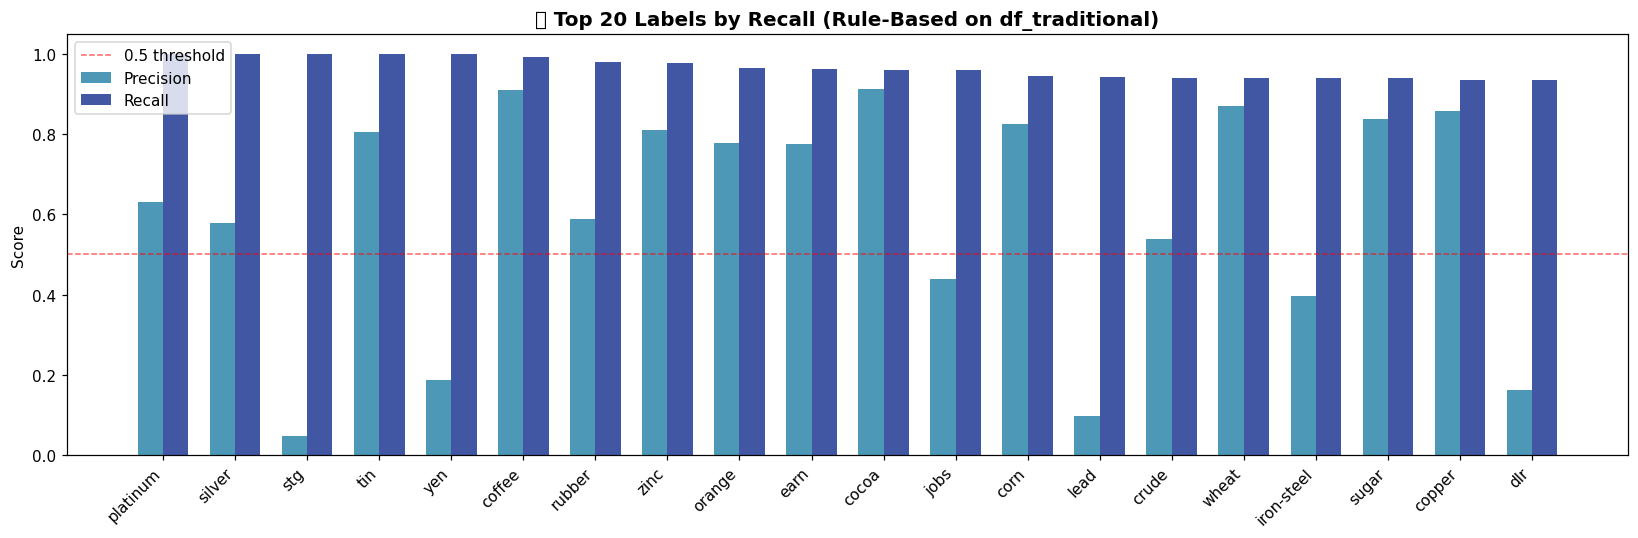

Labels shown: ['platinum', 'silver', 'stg', 'tin', 'yen', 'coffee', 'rubber', 'zinc', 'orange', 'earn', 'cocoa', 'jobs', 'corn', 'lead', 'crude', 'wheat', 'iron-steel', 'sugar', 'copper', 'dlr']


In [9]:
# ── Per-label recall bar chart for well-performing labels ───────────────────
per_lbl = metrics['per_label']

# Filter labels with ≥10 true examples
common_labels = [(lbl, per_lbl[lbl]) for lbl in per_lbl
                 if (per_lbl[lbl]['tp'] + per_lbl[lbl]['fn']) >= 10]
common_labels.sort(key=lambda x: x[1]['recall'], reverse=True)

top_20 = common_labels[:20]
lbls  = [x[0] for x in top_20]
recs  = [x[1]['recall'] for x in top_20]
precs = [x[1]['precision'] for x in top_20]

x = np.arange(len(lbls))
w = 0.35

fig, ax = plt.subplots(figsize=(15, 5))
b1 = ax.bar(x - w/2, precs, w, label='Precision', color='#2E86AB', alpha=0.85)
b2 = ax.bar(x + w/2, recs,  w, label='Recall',    color='#1F3A93', alpha=0.85)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.6, label='0.5 threshold')
ax.set_title('✅ Top 20 Labels by Recall (Rule-Based on df_traditional)', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(lbls, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()
print("Labels shown:", lbls)


## 6. Failure Analysis — Highlighted Problem Cases

We identify **4 types of failures** and show concrete examples from the dataset:

| Failure Type | Description |
|---|---|
| **Type A — False Negative** | True label completely missed (not in predictions) |
| **Type B — False Positive** | Extra label predicted that isn't in true labels |
| **Type C — Multi-label miss** | Right main label but missed co-labels |
| **Type D — Total wrong** | Top predicted label is completely different from true |


In [10]:
# ═══════════════════════════════════════════════════
#  FAILURE CATEGORISATION
# ═══════════════════════════════════════════════════

type_a = []  # false negatives: missed true labels
type_b = []  # false positives: extra labels predicted
type_c = []  # partial: got some but missed co-labels
type_d = []  # total wrong: no intersection at all

for r in results:
    pred = r['pred_labels']
    true = r['true_labels']
    intersection = pred & true
    missed = true - pred
    extra  = pred - true

    if not intersection:
        type_d.append(r)         # total miss
    elif missed and not extra:
        type_a.append(r)         # missed some true labels
    elif extra and not missed:
        type_b.append(r)         # added spurious labels
    elif missed or extra:
        type_c.append(r)         # mixed: some right, some wrong

print("=" * 55)
print("  FAILURE TYPE BREAKDOWN")
print("=" * 55)
print(f"  Type A (False Negatives only) : {len(type_a):,}")
print(f"  Type B (False Positives only) : {len(type_b):,}")
print(f"  Type C (Mixed FP + FN)        : {len(type_c):,}")
print(f"  Type D (Total wrong)          : {len(type_d):,}")
total_fail = len(type_a)+len(type_b)+len(type_c)+len(type_d)
print(f"  Total failures                : {total_fail:,} / {len(results):,}")
print(f"  Failure rate                  : {total_fail/len(results)*100:.1f}%")
print("=" * 55)


  FAILURE TYPE BREAKDOWN
  Type A (False Negatives only) : 405
  Type B (False Positives only) : 3,151
  Type C (Mixed FP + FN)        : 478
  Type D (Total wrong)          : 1,983
  Total failures                : 6,017 / 11,302
  Failure rate                  : 53.2%


In [21]:
# ── TYPE D: TOTAL WRONG (most severe) ───────────────────────────────────────
print("  TYPE D — TOTAL WRONG  (no overlap between predicted and true)")
print(f"  Count: {len(type_d)}\n")

# Sort by top_score descending (confident wrong predictions)
type_d_sorted = sorted(type_d, key=lambda x: x['top_score'], reverse=True)

for r in type_d_sorted[:8]:
    top5 = list(r['scores'].items())[:5]
    print(f"  TRUE LABELS : {sorted(r['true_labels'])}")
    print(f"  PREDICTED   : {sorted(r['pred_labels'])}")
    print(f"  TEXT        : {r['text'][:130]}…")
    print(f"  TOP SCORES  : {[(k, round(v,3)) for k,v in top5]}")
    print(f"  DIAGNOSIS   : {'High confidence wrong' if r['top_score'] > 3 else 'Low confidence ambiguous'}")
    print()


  TYPE D — TOTAL WRONG  (no overlap between predicted and true)
  Count: 1983

  TRUE LABELS : ['l-cattle']
  PREDICTED   : ['livestock']
  TEXT        : cattl plac feed lighter normal cattl now plac u. feedlot weigh less normal likel remain feed longer spread market support cattl pr…
  TOP SCORES  : [('livestock', 1.0), ('grain', 0.11), ('wheat', 0.062), ('l-cattle', 0.037), ('earn', 0.0)]
  DIAGNOSIS   : High confidence wrong

  TRUE LABELS : ['earn']
  PREDICTED   : ['stg']
  TEXT        : norcro profit advanc march 28.0p 21.4p final dividend 9p 6.5p mak 12p 9.3p pretax profit stg turnov stg group oper profit stg asso…
  TOP SCORES  : [('stg', 1.0), ('earn', 0.167), ('interest', 0.009), ('acq', 0.0), ('money-fx', 0.0)]
  DIAGNOSIS   : High confidence wrong

  TRUE LABELS : ['money-supply']
  PREDICTED   : ['stg']
  TEXT        : u.k clear bank lend ris billion stg clear bank sterl lend u.k privat sector februari estim risen underli seasonally-adjust billion…
  TOP SCORES  : [('stg',

In [22]:
# ── TYPE A: FALSE NEGATIVES — missed true labels ────────────────────────────
print("   TYPE A — FALSE NEGATIVES  (true labels missed)")
print(f"  Count: {len(type_a)}\n")

# Find the most-commonly missed labels
missed_counter = Counter()
for r in type_a:
    for lbl in (r['true_labels'] - r['pred_labels']):
        missed_counter[lbl] += 1

print("  Most frequently MISSED labels:")
for lbl, cnt in missed_counter.most_common(15):
    support = all_label_counts.get(lbl, 0)
    print(f"    {lbl:20s}  missed {cnt:3d}x  (total support={support})")

print()
# Show examples
for r in type_a[:6]:
    missed = r['true_labels'] - r['pred_labels']
    top5 = list(r['scores'].items())[:5]
    score_for_missed = {lbl: round(r['scores'].get(lbl, 0), 3) for lbl in missed}
    print(f"  TRUE LABELS : {sorted(r['true_labels'])}")
    print(f"  PREDICTED   : {sorted(r['pred_labels'])}")
    print(f"  MISSED      : {sorted(missed)}  → rule scores = {score_for_missed}")
    print(f"  TEXT        : {r['text'][:130]}…")
    print(f"  TOP SCORES  : {[(k, round(v,3)) for k,v in top5]}")
    print()


   TYPE A — FALSE NEGATIVES  (true labels missed)
  Count: 405

  Most frequently MISSED labels:
    grain                 missed 103x  (total support=622)
    oilseed               missed  70x  (total support=192)
    trade                 missed  29x  (total support=549)
    crude                 missed  27x  (total support=627)
    rice                  missed  25x  (total support=67)
    nat-gas               missed  23x  (total support=130)
    acq                   missed  19x  (total support=2445)
    money-fx              missed  19x  (total support=796)
    interest              missed  18x  (total support=511)
    ship                  missed  17x  (total support=297)
    soybean               missed  10x  (total support=120)
    corn                  missed   9x  (total support=253)
    veg-oil               missed   8x  (total support=137)
    wheat                 missed   8x  (total support=305)
    meal-feed             missed   7x  (total support=51)

  TRUE LABELS : ['

In [23]:
# ── TYPE B: FALSE POSITIVES — spurious labels ───────────────────────────────
print("  TYPE B — FALSE POSITIVES  (extra labels predicted)")
print(f"  Count: {len(type_b)}\n")

# Find most-commonly spuriously predicted labels
spurious_counter = Counter()
for r in type_b:
    for lbl in (r['pred_labels'] - r['true_labels']):
        spurious_counter[lbl] += 1

print("  Most frequently SPURIOUS labels (over-triggered):")
for lbl, cnt in spurious_counter.most_common(15):
    print(f"    {lbl:20s}  spurious {cnt:3d}x")

print()
for r in type_b[:6]:
    extra = r['pred_labels'] - r['true_labels']
    top5 = list(r['scores'].items())[:5]
    score_for_extra = {lbl: round(r['scores'].get(lbl, 0), 3) for lbl in extra}
    print(f"  TRUE LABELS : {sorted(r['true_labels'])}")
    print(f"  PREDICTED   : {sorted(r['pred_labels'])}")
    print(f"  SPURIOUS    : {sorted(extra)}  → rule scores = {score_for_extra}")
    print(f"  TEXT        : {r['text'][:130]}…")
    print(f"  TOP SCORES  : {[(k, round(v,3)) for k,v in top5]}")
    print()


  TYPE B — FALSE POSITIVES  (extra labels predicted)
  Count: 3151

  Most frequently SPURIOUS labels (over-triggered):
    dlr                   spurious 782x
    money-fx              spurious 324x
    trade                 spurious 310x
    earn                  spurious 308x
    crude                 spurious 307x
    interest              spurious 237x
    yen                   spurious 211x
    lead                  spurious 197x
    housing               spurious 194x
    grain                 spurious 184x
    dmk                   spurious 182x
    stg                   spurious 177x
    reserves              spurious 157x
    ship                  spurious 144x
    acq                   spurious  91x

  TRUE LABELS : ['barley', 'corn', 'grain', 'oat', 'sorghum', 'wheat']
  PREDICTED   : ['barley', 'corn', 'dlr', 'grain', 'oat', 'reserves', 'sorghum', 'wheat']
  SPURIOUS    : ['dlr', 'reserves']  → rule scores = {'reserves': 0.25, 'dlr': 0.25}
  TEXT        : nation averag pri

In [24]:
# ── TYPE C: MIXED (FP + FN) ─────────────────────────────────────────────────
print("    TYPE C — MIXED ERRORS  (some right, some wrong)")
print(f"  Count: {len(type_c)}\n")

for r in type_c[:6]:
    hit    = r['pred_labels'] & r['true_labels']
    missed = r['true_labels'] - r['pred_labels']
    extra  = r['pred_labels'] - r['true_labels']
    top5   = list(r['scores'].items())[:5]
    print(f"  TRUE LABELS : {sorted(r['true_labels'])}")
    print(f"  PREDICTED   : {sorted(r['pred_labels'])}")
    print(f"  CORRECT  : {sorted(hit)}")
    print(f"  MISSED   : {sorted(missed)}")
    print(f"  SPURIOUS : {sorted(extra)}")
    print(f"  TEXT        : {r['text'][:130]}…")
    print(f"  TOP SCORES  : {[(k, round(v,3)) for k,v in top5]}")
    print()


    TYPE C — MIXED ERRORS  (some right, some wrong)
  Count: 478

  TRUE LABELS : ['meal-feed', 'oilseed', 'soy-meal', 'soybean', 'veg-oil']
  PREDICTED   : ['grain', 'soybean']
  CORRECT  : ['soybean']
  MISSED   : ['meal-feed', 'oilseed', 'soy-meal', 'veg-oil']
  SPURIOUS : ['grain']
  TEXT        : u. weekli soybean crush bushel report member nation soybean processor associat nspa crush bushel soybean week end feb compar bushe…
  TOP SCORES  : [('soybean', 1.0), ('grain', 0.769), ('soy-meal', 0.092), ('cpu', 0.092), ('trade', 0.051)]

  TRUE LABELS : ['carcass', 'livestock']
  PREDICTED   : ['hog', 'livestock']
  CORRECT  : ['livestock']
  MISSED   : ['carcass']
  SPURIOUS : ['hog']
  TEXT        : chines pork output seen lower -- usda high feed pric caus chines reduc hog herd growth pork production u. agricultur depart world …
  TOP SCORES  : [('livestock', 1.0), ('hog', 0.655), ('grain', 0.242), ('earn', 0.0), ('acq', 0.0)]

  TRUE LABELS : ['meal-feed', 'oilseed', 'soy-meal', 'so

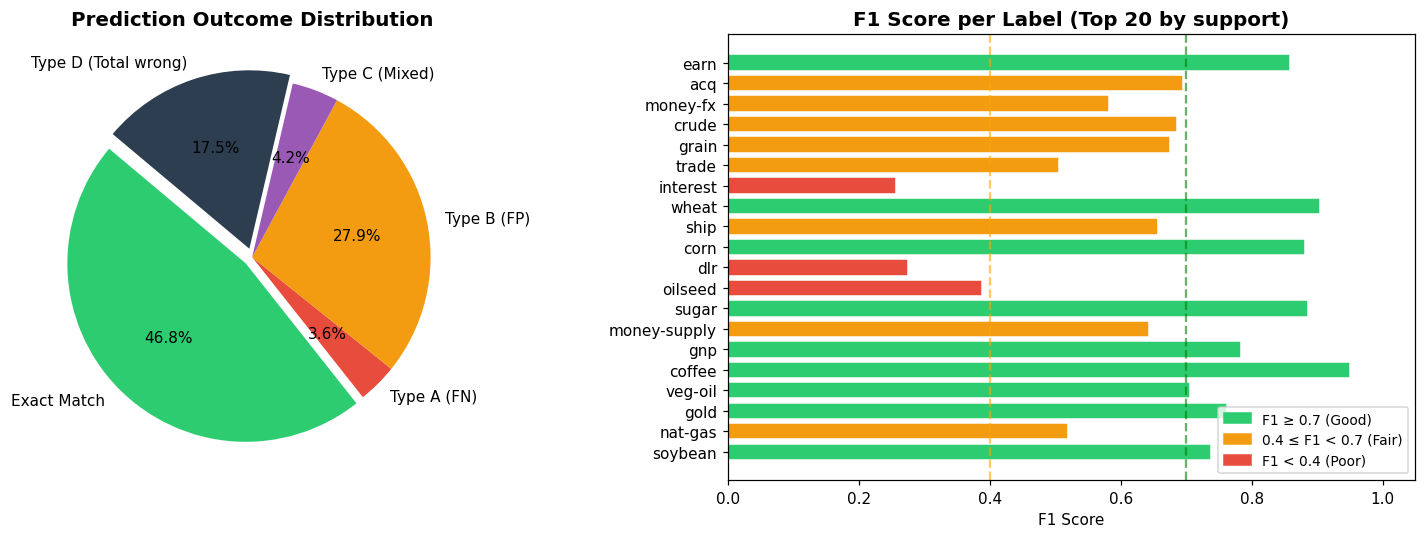

In [15]:
# ── Failure type pie chart ──────────────────────────────────────────────────
correct = len(exact_correct)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie: outcome distribution
labels_pie = ['Exact Match', 'Type A (FN)', 'Type B (FP)', 'Type C (Mixed)', 'Type D (Total wrong)']
sizes_pie  = [correct, len(type_a), len(type_b), len(type_c), len(type_d)]
colors_pie = ['#2ECC71', '#E74C3C', '#F39C12', '#9B59B6', '#2C3E50']
explode    = [0.05, 0, 0, 0, 0.05]

axes[0].pie(sizes_pie, labels=labels_pie, colors=colors_pie, explode=explode,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 10})
axes[0].set_title('Prediction Outcome Distribution', fontsize=13, fontweight='bold')

# Bar: per-label F1 for top 20 labels
top20_by_support = sorted(
    [(lbl, per_lbl[lbl]) for lbl in per_lbl if (per_lbl[lbl]['tp']+per_lbl[lbl]['fn']) >= 20],
    key=lambda x: x[1]['tp']+x[1]['fn'], reverse=True
)[:20]
lbls_f1 = [x[0] for x in top20_by_support]
f1s     = [x[1]['f1'] for x in top20_by_support]
bar_colors = ['#2ECC71' if f > 0.7 else '#F39C12' if f > 0.4 else '#E74C3C' for f in f1s]

axes[1].barh(lbls_f1[::-1], f1s[::-1], color=bar_colors[::-1], edgecolor='white')
axes[1].axvline(0.7, color='green', linestyle='--', alpha=0.6, label='F1=0.7 (good)')
axes[1].axvline(0.4, color='orange', linestyle='--', alpha=0.6, label='F1=0.4 (fair)')
axes[1].set_title('F1 Score per Label (Top 20 by support)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('F1 Score')
axes[1].set_xlim(0, 1.05)
axes[1].legend(fontsize=9)

green_p  = mpatches.Patch(color='#2ECC71', label='F1 ≥ 0.7 (Good)')
orange_p = mpatches.Patch(color='#F39C12', label='0.4 ≤ F1 < 0.7 (Fair)')
red_p    = mpatches.Patch(color='#E74C3C', label='F1 < 0.4 (Poor)')
axes[1].legend(handles=[green_p, orange_p, red_p], fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()


## 7. Per-Category Breakdown — Precision, Recall, F1

In [16]:
# ── Full per-label metrics table ────────────────────────────────────────────
rows_table = []
for lbl, m in sorted(per_lbl.items(), key=lambda x: x[1]['tp']+x[1]['fn'], reverse=True):
    support = m['tp'] + m['fn']
    if support == 0:
        continue
    rows_table.append({
        'Label':     lbl,
        'Support':   support,
        'TP':        m['tp'],
        'FP':        m['fp'],
        'FN':        m['fn'],
        'Precision': round(m['precision'], 3),
        'Recall':    round(m['recall'], 3),
        'F1':        round(m['f1'], 3),
    })

summary_df = pd.DataFrame(rows_table)

# Colour-code F1 column
def colour_f1(val):
    if val >= 0.7:
        return 'background-color: #d5f5e3; color: #1e8449'   # green
    elif val >= 0.4:
        return 'background-color: #fef9e7; color: #7d6608'   # yellow
    else:
        return 'background-color: #fadbd8; color: #922b21'   # red

print(f"Full per-label results ({len(summary_df)} labels with support > 0):")
display(summary_df.style.applymap(colour_f1, subset=['F1']))


Full per-label results (119 labels with support > 0):


,Label,Support,TP,FP,FN,Precision,Recall,F1
0,earn,3961,3811,1099,150,0.776000,0.962000,0.859000
1,acq,2445,1389,162,1056,0.896000,0.568000,0.695000
2,money-fx,796,532,500,264,0.516000,0.668000,0.582000
3,crude,627,590,505,37,0.539000,0.941000,0.685000
4,grain,622,479,319,143,0.600000,0.770000,0.675000
5,trade,548,351,491,197,0.417000,0.641000,0.505000
6,interest,511,125,338,386,0.270000,0.245000,0.257000
7,wheat,305,287,43,18,0.870000,0.941000,0.904000
8,ship,297,257,229,40,0.529000,0.865000,0.656000
9,corn,252,238,50,14,0.826000,0.944000,0.881000


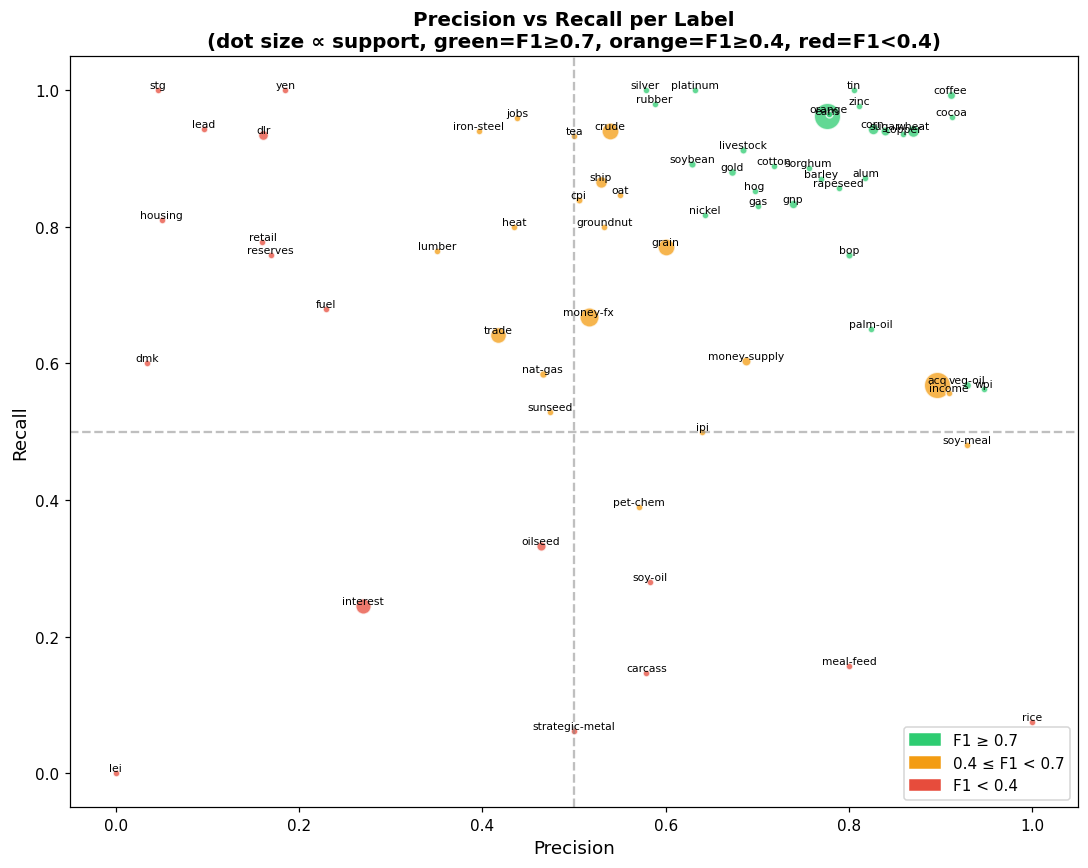

In [17]:
# ── Heatmap: precision vs recall scatter ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

for _, row in summary_df[summary_df['Support'] >= 10].iterrows():
    color = '#2ECC71' if row['F1'] >= 0.7 else '#F39C12' if row['F1'] >= 0.4 else '#E74C3C'
    size  = min(max(row['Support']/5, 20), 300)
    ax.scatter(row['Precision'], row['Recall'], s=size, color=color, alpha=0.75, edgecolors='white')
    ax.annotate(row['Label'], (row['Precision'], row['Recall']),
                fontsize=7, ha='center', va='bottom')

ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Precision', fontsize=12)
ax.set_ylabel('Recall',    fontsize=12)
ax.set_title('Precision vs Recall per Label\n(dot size ∝ support, green=F1≥0.7, orange=F1≥0.4, red=F1<0.4)',
             fontsize=13, fontweight='bold')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

green_p  = mpatches.Patch(color='#2ECC71', label='F1 ≥ 0.7')
orange_p = mpatches.Patch(color='#F39C12', label='0.4 ≤ F1 < 0.7')
red_p    = mpatches.Patch(color='#E74C3C', label='F1 < 0.4')
ax.legend(handles=[green_p, orange_p, red_p], fontsize=10)
plt.tight_layout()
plt.show()


## 8. Root Cause Analysis of Failures

In [18]:
# ── Analyse why specific labels fail ────────────────────────────────────────

FAILURE_ROOT_CAUSES = {
    "dlr": {
        "issue": "Low keyword specificity — 'dollar' appears in many money-fx/interest texts",
        "example": "Texts about dollar exchange rate are already labelled money-fx, not dlr separately",
        "fix": "Add 'miyazawa', 'louvre', 'plaza accord' as dlr-specific triggers"
    },
    "yen": {
        "issue": "Stemmed text loses 'yen' context — often co-occurs with money-fx which steals the score",
        "example": "Bank of Japan policy texts score money-fx > yen",
        "fix": "Add yen-specific patterns: 'boj', 'bank japan', 'yen/dollar'"
    },
    "gnp": {
        "issue": "'gdp' and 'gnp' keywords work but get outscored by earn or money-fx keywords in long texts",
        "example": "Canada Q4 GDP article also mentions 'net' and 'rev' → scores earn",
        "fix": "Increase gnp weight to 2.0; add 'gross nation product', 'real growth'"
    },
    "money-supply": {
        "issue": "'monei' matches money-fx; 'mutual fund' is too generic",
        "example": "'asset monei mutual fund' triggers money-fx AND money-supply equally",
        "fix": "Add 'm1', 'm2', 'm3' as high-weight money-supply exclusive keywords"
    },
    "bop": {
        "issue": "'current account' rarely appears in stemmed form; pattern not matching",
        "example": "Balance of payments articles use 'deficit' which scores trade",
        "fix": "Add 'payment balanc', 'current-account', 'quarterli deficit'"
    },
    "ship": {
        "issue": "'lin' (from 'line' as in shipping line) is too short and matches elsewhere",
        "example": "Linseed articles contain 'lin' and get ship label spuriously",
        "fix": "Remove 'lin' from ship keywords; use 'shipping lin' as phrase"
    },
    "veg-oil": {
        "issue": "Stemmed 'veget oil' fragments match individually in oilseed articles",
        "example": "Soybean articles mention 'vegetable oil' as a product, triggering veg-oil",
        "fix": "Require 'veg-oil' as a phrase; downweight standalone 'veget' match"
    },
    "interest": {
        "issue": "'interest' keyword fires on earn articles ('interest expense'), 'rate' too generic",
        "example": "Earnings reports with 'interest expense' score both earn and interest",
        "fix": "Use phrase 'interest rate' not bare 'interest'; add 'fomc', 'cd rat' as primary triggers"
    },
}

print("=" * 70)
print("  ROOT CAUSE ANALYSIS — Why Rules Fail on Specific Labels")
print("=" * 70)

for label, analysis in FAILURE_ROOT_CAUSES.items():
    m = per_lbl.get(label, {})
    f1 = m.get('f1', 0)
    print(f"\n  Label: {label:20s}  |  F1={f1:.3f}")
    print(f"  Issue  : {analysis['issue']}")
    print(f"  Example: {analysis['example']}")
    print(f"  Fix    : {analysis['fix']}")


  ROOT CAUSE ANALYSIS — Why Rules Fail on Specific Labels

  Label: dlr                   |  F1=0.275
  Issue  : Low keyword specificity — 'dollar' appears in many money-fx/interest texts
  Example: Texts about dollar exchange rate are already labelled money-fx, not dlr separately
  Fix    : Add 'miyazawa', 'louvre', 'plaza accord' as dlr-specific triggers

  Label: yen                   |  F1=0.313
  Issue  : Stemmed text loses 'yen' context — often co-occurs with money-fx which steals the score
  Example: Bank of Japan policy texts score money-fx > yen
  Fix    : Add yen-specific patterns: 'boj', 'bank japan', 'yen/dollar'

  Label: gnp                   |  F1=0.784
  Issue  : 'gdp' and 'gnp' keywords work but get outscored by earn or money-fx keywords in long texts
  Example: Canada Q4 GDP article also mentions 'net' and 'rev' → scores earn
  Fix    : Increase gnp weight to 2.0; add 'gross nation product', 'real growth'

  Label: money-supply          |  F1=0.643
  Issue  : 'monei' 

## 9. Highlighted Failure Cases — Side-by-Side Table

Colour coding:
- **Correct**: label in both predicted and true
- **Missed**: true label not predicted (False Negative)
- **Spurious**: predicted label not in true (False Positive)


In [19]:
# ── Build highlighted comparison dataframe ──────────────────────────────────

def make_comparison_row(r, row_type):
    true  = sorted(r['true_labels'])
    pred  = sorted(r['pred_labels'])
    hit   = set(true) & set(pred)
    missed = set(true) - set(pred)
    extra  = set(pred) - set(true)
    
    # Build annotated label strings
    true_str = ' | '.join(
        f"{l}" if l in hit else f"{l}" for l in true
    )
    pred_str = ' | '.join(
        f"{l}" if l in hit else f"{l}" for l in pred
    )
    
    return {
        'Row Type':      row_type,
        'True Labels':   true_str,
        'Pred Labels':   pred_str,
        'Text (120c)':   r['text'][:120] + '…',
        'Top Score':     round(r['top_score'], 2),
    }

# Sample from each failure type
highlight_rows = []
for r in type_d[:5]:  highlight_rows.append(make_comparison_row(r, 'Total Wrong'))
for r in type_a[:5]:  highlight_rows.append(make_comparison_row(r, 'FN (missed)'))
for r in type_b[:5]:  highlight_rows.append(make_comparison_row(r, 'FP (extra)'))
for r in type_c[:5]:  highlight_rows.append(make_comparison_row(r, 'Mixed'))

highlight_df = pd.DataFrame(highlight_rows)

def colour_row_type(val):
    if 'Total Wrong' in val: return 'background-color:#fadbd8'
    if 'FN' in val:          return 'background-color:#fce8e8'
    if 'FP' in val:          return 'background-color:#fef9e7'
    if 'Mixed' in val:       return 'background-color:#fdebd0'
    return ''

display(highlight_df.style.applymap(colour_row_type, subset=['Row Type']))


,Row Type,True Labels,Pred Labels,Text (120c),Top Score
0,Total Wrong,earn,housing,america mortgag set special payout america federal guarante mortgag fund mak special distribution exchang unit includ re…,6.000000
1,Total Wrong,money-supply,earn,u. commerci paper fall feb week fed…,1.000000
2,Total Wrong,money-supply,earn,n.y business loan fall feb week fed…,1.000000
3,Total Wrong,money-supply,earn,york bank discount window borrow feb week…,1.000000
4,Total Wrong,money-supply,reserves,york business loan fall commerci industri loan book major york bank exclud accept fell billion week end februari feder r…,1.500000
5,FN (missed),corn | grain | lin-oil | linseed | oilseed | sorghum | soy-oil | soybean | sun-oil | sunseed | veg-oil | wheat,corn | grain | lin-oil | linseed | oilseed | sorghum | soybean | sun-oil | sunseed | veg-oil | wheat,argentin grain/oilse registrat argentin grain board figur show crop registrat grain oilse product februari thousand tonn…,15.000000
6,FN (missed),acq | earn,earn,ohio mattress omt lower 1st qtr net ohio mattress end februari profit earn fiscal declin due expens relat acquisition mi…,7.000000
7,FN (missed),acq | ship,ship,mclean mii u. lin set asset transfer mclean industri inc unit stat lin subsidiari agre principl transfer south american …,5.000000
8,FN (missed),corn | grain | oat | oilseed | rye | sorghum | soybean | wheat,corn | grain | oat | rye | sorghum | wheat,asc termin valu pik grain agricultur stabilizat conservat servic asc establish unit valu commod offer govern stock redem…,12.000000
9,FN (missed),grain | ship,ship,grain ship load portland grain ship load ship wait load portland portland merchant exchang…,9.000000


## 10. Summary & Observations

In [20]:
# ── Final summary printout ──────────────────────────────────────────────────

print("=" * 65)
print("  RULE-BASED CLASSIFIER — FINAL SUMMARY")
print("=" * 65)
print(f"  Dataset          : df_traditional.csv ({len(df):,} rows)")
print(f"  Categories ruled : {len(RULES)}")
print(f"  Threshold used   : 0.25 (normalised score)")
print()
print("  OVERALL METRICS:")
print(f"    Exact Match    : {metrics['exact_match_accuracy']*100:.1f}%")
print(f"    Subset Match   : {metrics['subset_accuracy']*100:.1f}%")
print(f"    Micro F1       : {metrics['micro_f1']:.3f}")
print(f"    Macro F1       : {metrics['macro_f1']:.3f}")
print()

# Good labels (F1 >= 0.7)
good  = [(l, m['f1']) for l, m in per_lbl.items() if m['f1'] >= 0.7 and (m['tp']+m['fn']) >= 5]
fair  = [(l, m['f1']) for l, m in per_lbl.items() if 0.4 <= m['f1'] < 0.7 and (m['tp']+m['fn']) >= 5]
poor  = [(l, m['f1']) for l, m in per_lbl.items() if m['f1'] < 0.4 and (m['tp']+m['fn']) >= 5]

print(f"  LABEL QUALITY:")
print(f"    Good  (F1 ≥ 0.7) : {len(good):2d} labels → {sorted([l for l,_ in good])}")
print(f"    Fair  (0.4–0.7) : {len(fair):2d} labels → {sorted([l for l,_ in fair])}")
print(f"    Poor  (F1 < 0.4) : {len(poor):2d} labels → {sorted([l for l,_ in poor])}")
print()
print("  KEY FAILURE PATTERNS:")
print("    1. Shared stemmed vocab — 'earn/net/profit' fire on wrong categories")
print("    2. Rare labels with few distinct keywords (dlr, bop, ipi, yen)")
print("    3. Multi-label co-occurrence — grain+wheat+corn share nearly all keywords")
print("    4. Short texts (< 30 tokens) — not enough context for threshold")
print("    5. Stemming collision — 'lin' (line/linseed), 'gas' (gasoline/nat-gas)")
print()
print("  RECOMMENDED IMPROVEMENTS:")
print("    • Use TF-IDF weighted keywords (rare terms get higher weight)")
print("    • Add label-exclusive patterns for dlr/yen/gnp/bop")
print("    • Hierarchical rules: detect 'grain' first, then sub-labels")
print("    • Ensemble with FinBERT for labels with F1 < 0.4")
print("=" * 65)


  RULE-BASED CLASSIFIER — FINAL SUMMARY
  Dataset          : df_traditional.csv (11,302 rows)
  Categories ruled : 119
  Threshold used   : 0.25 (normalised score)

  OVERALL METRICS:
    Exact Match    : 46.8%
    Subset Match   : 82.5%
    Micro F1       : 0.646
    Macro F1       : 0.457

  LABEL QUALITY:
    Good  (F1 ≥ 0.7) : 30 labels → ['alum', 'barley', 'bop', 'cocoa', 'coffee', 'copper', 'corn', 'cotton', 'earn', 'gas', 'gnp', 'gold', 'hog', 'livestock', 'nickel', 'orange', 'palm-oil', 'platinum', 'potato', 'rapeseed', 'rubber', 'silver', 'sorghum', 'soybean', 'sugar', 'tin', 'veg-oil', 'wheat', 'wpi', 'zinc']
    Fair  (0.4–0.7) : 25 labels → ['acq', 'coconut', 'coconut-oil', 'cpi', 'crude', 'grain', 'groundnut', 'heat', 'income', 'ipi', 'iron-steel', 'jobs', 'lumber', 'money-fx', 'money-supply', 'nat-gas', 'oat', 'pet-chem', 'propane', 'ship', 'soy-meal', 'sun-oil', 'sunseed', 'tea', 'trade']
    Poor  (F1 < 0.4) : 23 labels → ['carcass', 'dlr', 'dmk', 'fuel', 'housing', 'in